In [1]:
%config IPCompleter.greedy=True

In [2]:
%pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [4]:
L, N, rho0 = 1, 50, 1
h = L/N
x = np.linspace(0, L, N+1)
x_int = x[1:-1]
sin_color, num_color = "#32a850", "#10135e"

In [5]:
def sin_charge(x: float) -> tuple[float, float]:
    L, rho0, epsilon0 = 1, 1, 1
    rho = (rho0 / epsilon0) * (L / np.pi)**2 * np.sin(np.pi * x / L)
    E = -(rho0 / epsilon0) * (L / np.pi) * np.cos(np.pi * x / L)
    
    return rho, E

sin_rho_a, sin_E_a = sin_charge(x_int)

In [15]:
def diff_sin(N: float, x: list[float], h: float, rho0: float = 1) -> float:
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = rho0 * np.sin(np.pi * x / L)
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    phi_internal = np.linalg.solve(A, b)

    return phi_internal

def electric_field(x_int: list[float], phi_int: list[float]) -> list[float]:
    E = np.zeros(len(x_int))
    k = -1/(2*h)
    for i in range(1, len(x_int)-1):
        E[i] = (phi_int[i+1] - phi_int[i-1]) * k
    
    E[0] = (phi_int[1] - phi_int[0]) * 2 * k
    E[-1] = (phi_int[-1] - phi_int[-2]) * 2 * k

    return E
    
phi_int = diff_sin(N=50, x=x_int, h=h)
E = electric_field(x_int=x_int, phi_int=phi_int)

In [8]:
print(max(abs(phi_int - sin_charge(x_int)[0])))
print(max(abs(E-sin_E_a)))

3.3339914100094514e-05
0.0007324251872328214


In [9]:
Ns = np.array([10, 20, 40, 80, 160])
hs = L / Ns
errs = []

for i in range(len(Ns)):
    xs = np.linspace(0, L, Ns[i]+1)
    xs_int = xs[1:-1]
    rho_a, _ = sin_charge(xs_int)
    rho_n = diff_sin(N=Ns[i], x=xs_int, h=hs[i])
    errs.append(np.max(np.abs(rho_a - rho_n)))

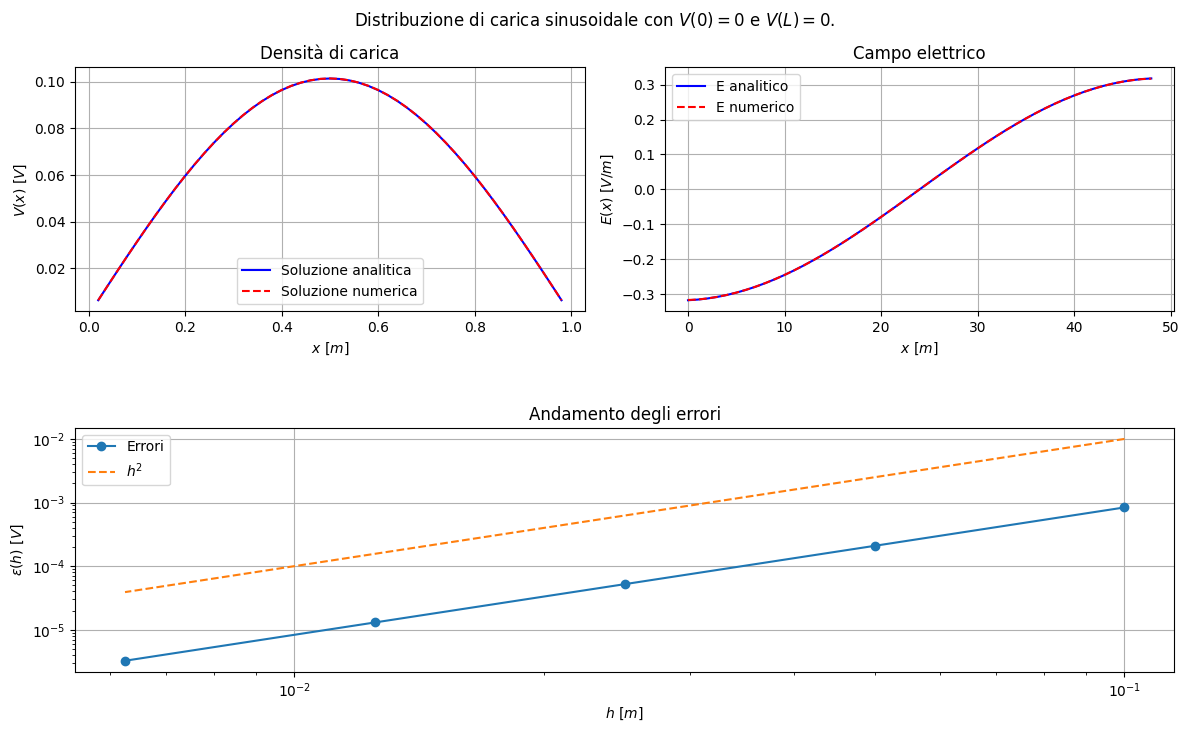

In [10]:
#fig, (ax1, ax2) = plt.subplots(1, 2)
fig, axd = plt.subplot_mosaic([['ax1', 'ax2'], ['ax3', 'ax3']])
ax1, ax2, ax3 = axd["ax1"], axd["ax2"], axd["ax3"]

ax1.plot(x_int, sin_rho_a, color="blue", label="Soluzione analitica")
ax1.plot(x_int, phi_int, "--", color="red", label="Soluzione numerica")
ax1.grid(True)
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"$V(x)\ [V]$")
ax1.set_title("Densità di carica")
ax1.legend()

ax2.plot(sin_E_a, color="blue", label="E analitico")
ax2.plot(E, "--", color="red", label="E numerico")
ax2.legend()
ax2.grid(True)
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"$E(x)\ [V/m]$")
ax2.set_title("Campo elettrico")

ax3.loglog(hs, errs, "-o", label="Errori")
ax3.plot(hs, hs**2, "--", label=r"$h^2$")
ax3.grid()
ax3.legend()
ax3.set_title("Andamento degli errori")
ax3.set_xlabel(r"$h\ [m]$")
ax3.set_ylabel(r"$\varepsilon(h)\ [V]$")

plt.suptitle(r"Distribuzione di carica sinusoidale con $V(0)=0$ e $V(L)=0$.")
plt.tight_layout(h_pad=3.5)
plt.show()

In [16]:
def cost_charge(x: float) -> float:
    L, rho0, epsilon0 = 1, 1, 1
    rho = (rho0 / (2 * epsilon0)) * x * (L - x)

    return rho

def diff_cost(N: float, x: list[float], h: float, rho0: float = 1) -> float:
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = np.ones(len(x)) * rho0
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    phi_internal = np.linalg.solve(A, b)

    return phi_internal

def electric_field(x_int: list[float], phi_int: list[float]) -> list[float]:
    E = np.zeros(len(x_int))
    k = -1/(2*h)
    for i in range(1, len(x_int)-1):
        E[i] = (phi_int[i+1] - phi_int[i-1]) * k
    
    E[0] = (phi_int[1] - phi_int[0]) * 2 * k
    E[-1] = (phi_int[-1] - phi_int[-2]) * 2 * k

    return E

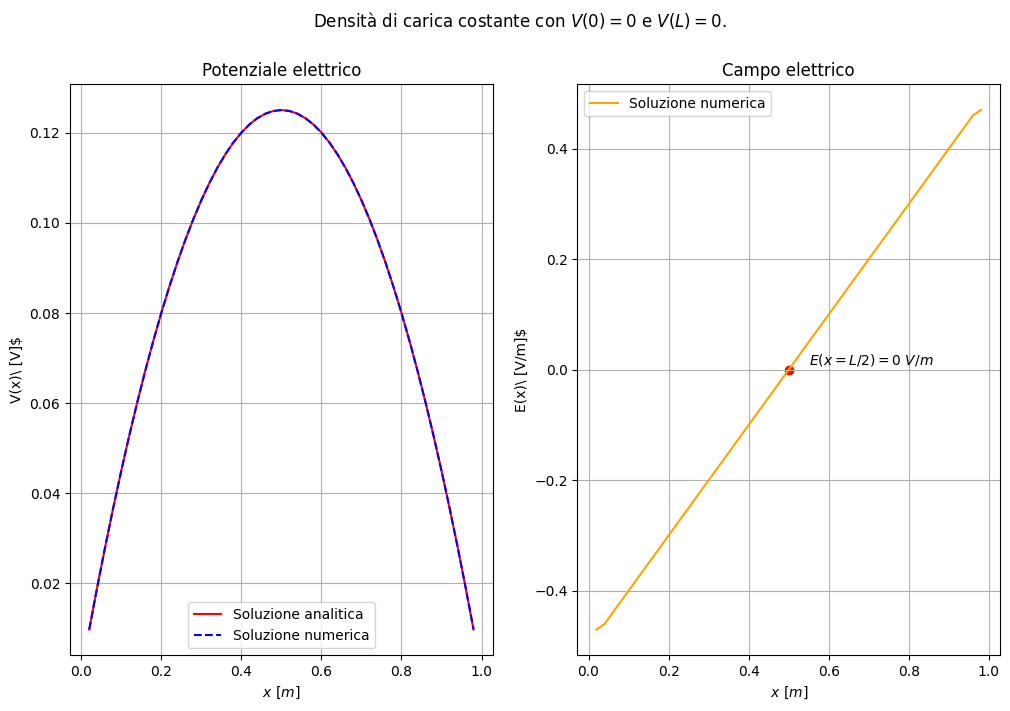

In [12]:
cost_rho = cost_charge(x=x_int)
cost_rho_num = diff_cost(N=50, x=x_int, h=h)
cost_E_num = electric_field(x_int=x_int, phi_int=cost_rho_num)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(x_int, cost_rho, color="red", label="Soluzione analitica")
ax1.plot(x_int, cost_rho_num, "--", color="blue", label="Soluzione numerica")
ax1.grid(True)
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"V(x)\ [V]$")
ax1.legend()
ax1.set_title("Potenziale elettrico")

ax2.plot(x_int, cost_E_num, color="orange", label="Soluzione numerica")
ax2.scatter(L/2, 0, color="red",)
ax2.text(0.55, 0.01, s=r"$E(x=L/2)=0\ V/m$")
ax2.grid(True)
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"E(x)\ [V/m]$")
ax2.legend()
ax2.set_title("Campo elettrico")

plt.suptitle(r"Densità di carica costante con $V(0)=0$ e $V(L)=0$.")
plt.show()

In [19]:
def cond_piano(x: float):
    L = 1
    Va, Vb = 0, 10
    return Va + (Vb - Va) * x / L

def diff_cond_piano(N: float, x: list[float], h: float, rho0: float = 0) -> float:
    Va, Vb = 0, 10
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = x * rho0
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    phi_internal = np.linalg.solve(A, b)

    return phi_internal


diff_cond_p = diff_cond_piano(50, x_int, h)
E_cond_piano = electric_field(x_int, diff_cond_p)

In [21]:
E_cond_piano

array([-10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10.])

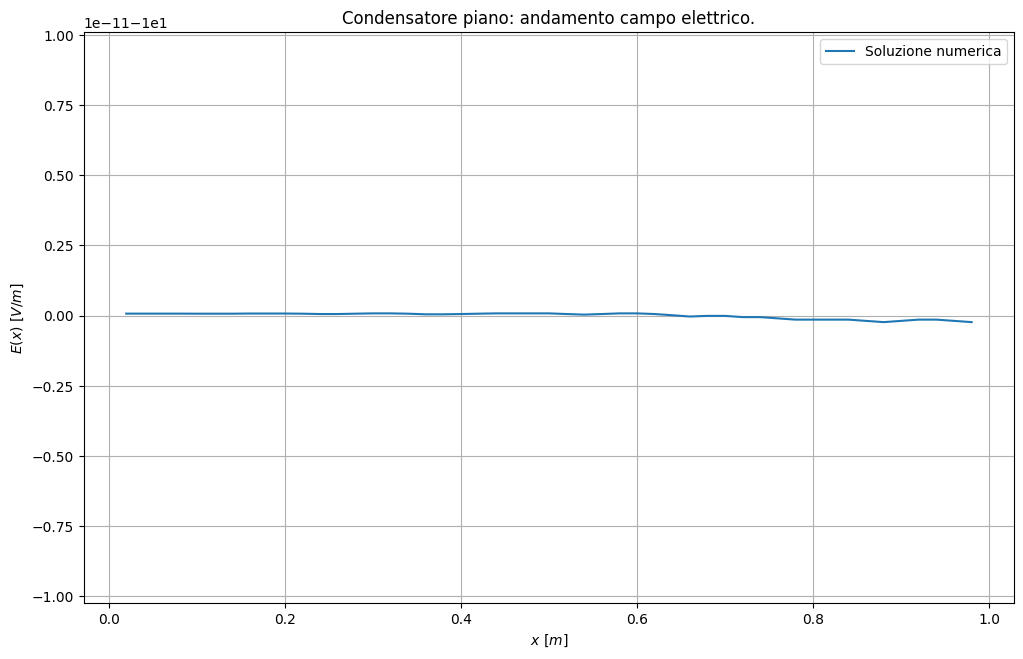

In [32]:
plt.plot(x_int, E_cond_piano, label="Soluzione numerica")
plt.grid()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$E(x)\ [V/m]$")
plt.legend()
plt.title("Condensatore piano: andamento campo elettrico.")
plt.show()

In [47]:
L1, sigma, N1 = 1, 0.1, 100
x1 = np.linspace(0, L1, N1+1)
x1_int = x1[1:-1]
h1 = L1/N1

def diff_gauss(N: int, x: list[float], h: float, L: int, sigma: float, rho0: float = 1):
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = rho0 * np.exp(-(x - L/2)**2 / (2 * sigma)**2)
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    phi_internal = np.linalg.solve(A, b)

    return phi_internal, b

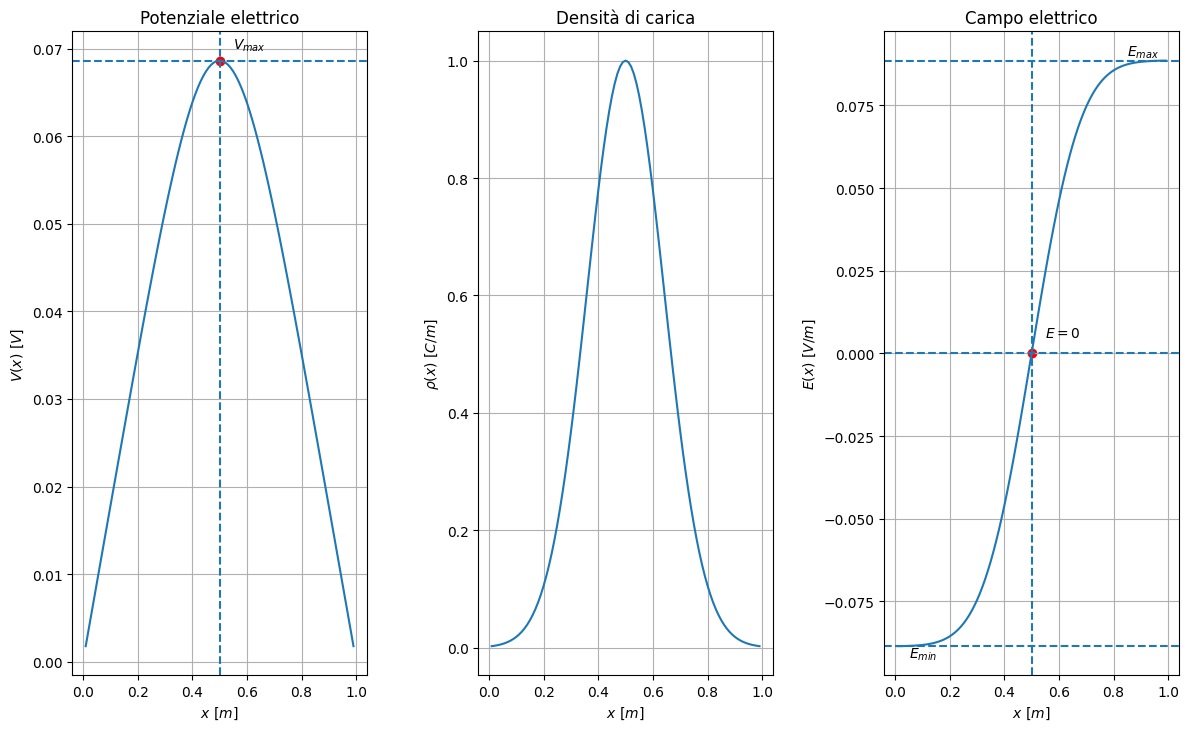

In [90]:
phi_gauss, rho_gauss = diff_gauss(N=N1, x=x1_int, h=h1, L=L1, sigma=sigma)
e_gauss = electric_field(x1_int, phi_gauss)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

ax1.plot(x1_int, phi_gauss)
ax1.axvline(L/2, ls="--")
ax1.axhline(np.max(phi_gauss), ls="--")
ax1.set_xlabel(r"$x\ [m]$")
ax1.set_ylabel(r"$V(x)\ [V]$")
ax1.grid(True)
ax1.set_title("Potenziale elettrico")
ax1.scatter(L1/2, np.max(phi_gauss), color="red")
ax1.text(L1/2 + 0.05, 0.07, s=r"$V_{max}$")

ax2.plot(x1_int, rho_gauss)
ax2.set_xlabel(r"$x\ [m]$")
ax2.set_ylabel(r"$\rho(x)\ [C/m]$")
ax2.grid(True)
ax2.set_title("Densità di carica")

ax3.plot(x1_int, e_gauss)
ax3.axvline(L/2, ls="--")
ax3.axhline(0, ls="--")
ax3.axhline(np.min(e_gauss), ls="--")
ax3.axhline(np.max(e_gauss), ls="--")
ax3.scatter(L/2, 0, color="red")
ax3.text(0.55, 0.005, s=r"$E=0$")
ax3.text(0.85, np.max(e_gauss)+0.0015, s=r"$E_{max}$")
ax3.text(0.05, np.min(e_gauss)-0.0035, s=r"$E_{min}$")
ax3.set_xlabel(r"$x\ [m]$")
ax3.set_ylabel(r"$E(x)\ [V/m]$")
ax3.grid(True)
ax3.set_title("Campo elettrico")

fig.tight_layout(w_pad=2.0)
plt.show()